In [1]:
# https://fred.stlouisfed.org/tags/series?t=corporate%3Bspread

import sys
# !{sys.executable} -m pip install -U xlrd

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

fred_dir = "Fred corp bond spreads"
fnames = ['AAA10Y.xls','BAA10Y.xls']

bond_spread_dict = dict()
for fn in fnames:
    bond_spread_dict[fn] = pd.read_excel(os.path.join(fred_dir,fn),'FRED Graph', skiprows=10)
bond_spread_dict

{'AAA10Y.xls':       observation_date  AAA10Y
 0           1983-01-03    1.45
 1           1983-01-04    1.42
 2           1983-01-05    1.44
 3           1983-01-06    1.35
 4           1983-01-07    1.38
 ...                ...     ...
 10474       2023-02-24    0.80
 10475       2023-02-27    0.81
 10476       2023-02-28    0.84
 10477       2023-03-01    0.77
 10478       2023-03-02    0.75
 
 [10479 rows x 2 columns],
 'BAA10Y.xls':      observation_date  BAA10Y
 0          1986-01-02    2.34
 1          1986-01-03    2.30
 2          1986-01-06    2.29
 3          1986-01-07    2.35
 4          1986-01-08    2.21
 ...               ...     ...
 9691       2023-02-24    1.86
 9692       2023-02-27    1.87
 9693       2023-02-28    1.90
 9694       2023-03-01    1.84
 9695       2023-03-02    1.82
 
 [9696 rows x 2 columns]}

In [2]:
corp_bond_spreads=bond_spread_dict[fnames[0]].merge(bond_spread_dict[fnames[1]], how='outer', 
                                                 left_on='observation_date', right_on='observation_date')
corp_bond_spreads.index = corp_bond_spreads['observation_date']
corp_bond_spreads = corp_bond_spreads[corp_bond_spreads['BAA10Y']> 0]
corp_bond_spreads['BAA_vs_AAA'] = corp_bond_spreads['BAA10Y'] - corp_bond_spreads['AAA10Y']

corp_bond_spreads

,observation_date,AAA10Y,BAA10Y,BAA_vs_AAA
observation_date,,,,
1986-01-02,1986-01-02,0.88,2.34,1.46
1986-01-03,1986-01-03,0.87,2.30,1.43
1986-01-06,1986-01-06,0.87,2.29,1.42
1986-01-07,1986-01-07,0.91,2.35,1.44
1986-01-08,1986-01-08,0.76,2.21,1.45
...,...,...,...,...
2023-02-24,2023-02-24,0.80,1.86,1.06
2023-02-27,2023-02-27,0.81,1.87,1.06
2023-02-28,2023-02-28,0.84,1.90,1.06


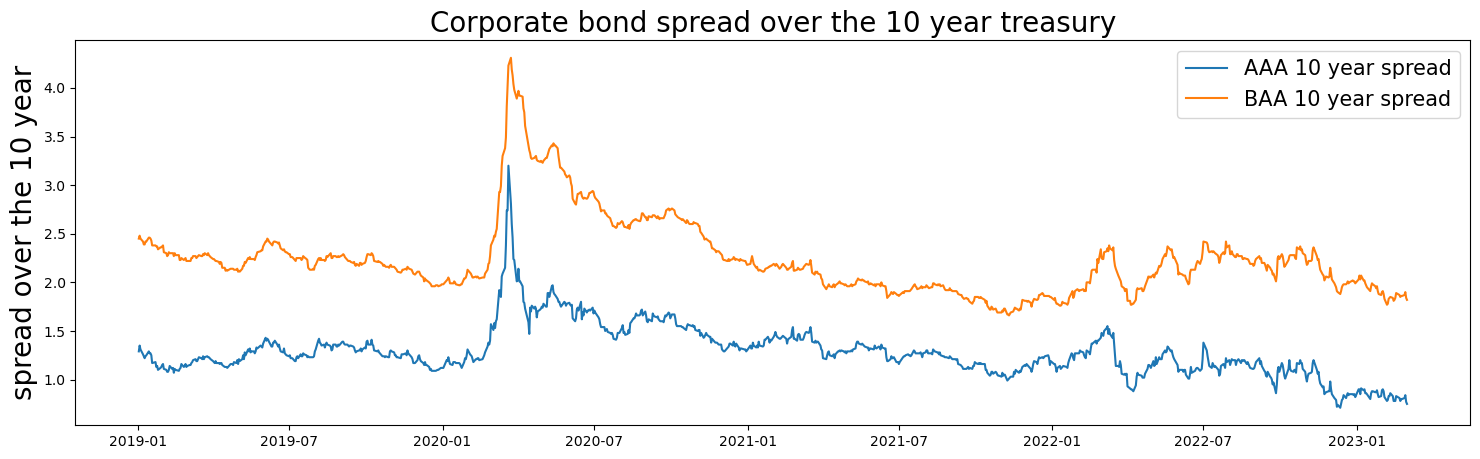

In [3]:
bond_spreads = corp_bond_spreads['2019-01-01':]

plt.figure(figsize=(18,5))
plt.plot(bond_spreads['AAA10Y'],'-', label="AAA 10 year spread")
plt.plot(bond_spreads['BAA10Y'],'-', label="BAA 10 year spread")
plt.title("Corporate bond spread over the 10 year treasury", fontsize=20)
plt.ylabel("spread over the 10 year", fontsize=20)
plt.legend(fontsize=15)
plt.show()

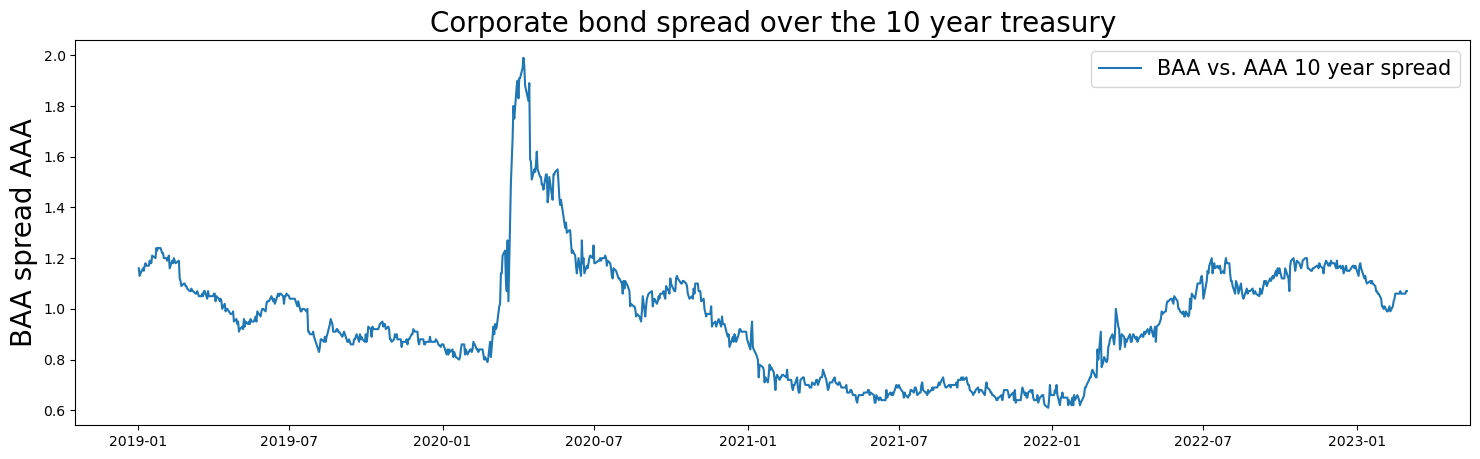

In [4]:
plt.figure(figsize=(18,5))
plt.plot(bond_spreads['BAA_vs_AAA'],'-', label="BAA vs. AAA 10 year spread")
plt.title("Corporate bond spread over the 10 year treasury", fontsize=20)
plt.ylabel("BAA spread AAA", fontsize=20)
plt.legend(fontsize=15)
plt.show()